# **EMPLOYEE WELLNESS ANALYSIS**  
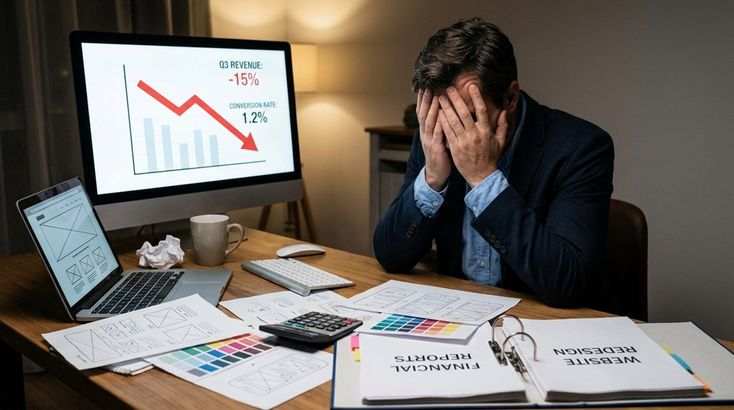

## **Authors**
ARYAN JAIN

PRAGYA VARSHNEY

SATVIK MISHRA

SHREYANS

## **INTRODUCTION**
### **PROBLEM STATEMENT**
XYZ Technical Solutions recently experienced the loss of an important employee, raising concerns about the overall mental health and well-being of its workforce. The company seeks to proactively identify employees who may currently need or may be at risk of needing mental health treatment. By analyzing employee demographics, workplace conditions, organizational support systems, and mental health-related factors, this study aims to uncover meaningful insights that can guide the development of effective wellness programs and preventive interventions.

### **OBJECTIVES OF THE ANALYSIS**
1. Understand the structure and characteristics of the employee wellness dataset.
2. Clean and preprocess the data by handling missing values, outliers, and inconsistencies.
3. Explore the distribution of demographic and workplace-related variables.
4. Analyze the relationship between employee characteristics and mental health treatment requirements.
5. Identify key factors that contribute to mental health challenges among employees.
6. Provide data-driven recommendations to improve employee wellness programs and organizational support systems.
7. Help the organization identify employees who may be at risk and require additional mental health support.

## **DATA OVERVIEW**

The description of the data attributes is given below:

• Timestamp

• Age

• Gender

• Country

• state: If you live in the United States, which state or territory do you live in?

• self_employed: Are you self-employed?

• family_history: Do you have a family history of mental illness?

• treatment: Does he or she really needs treatment.

• work_interfere: If you have a mental health condition, do you feel that it interferes with your work?

• no_employees: How many employees does your company or organization have?

• remote_work: Do you work remotely (outside of an office) at least 50% of the time?

• tech_company: Is your employer primarily a tech company/organization?

• benefits: Does your employer provide mental health benefits?

• care_options: Do you know the options for mental health care your employer provides?

• wellness_program: Has your employer ever discussed mental health as part of an employee wellness program?

• seek_help: Does your employer provide resources to learn more about mental health issues and how to seek help?

• anonymity: Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources?

• leave: How easy is it for you to take medical leave for a mental health condition?

• mental_health_consequence: Do you think that discussing a mental health issue with your employer would have negative consequences?


### **IMPORT LIBRARIES**

We will use the following libraries

*1. Pandas: Data manipulation and analysis*

*2. Numpy: Numerical operations and calculations*

*3. Matplotlib: Data visualization and plotting*

*4. Seaborn: Enhanced data visualization and statistical graphics*

*5. Scipy: Scientific computing and advanced mathematical operations*

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
# this is for jupyter notebook to show the plot in the notebook itself instead of opening a new window
%matplotlib inline

In [ ]:
import os

os.listdir('/content')

['.config', 'sample_data']

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

## **DATA LOADING AND EXPLORATION**

### Load CSV file and creating a dataframe.

In [ ]:
df=pd.read_csv("employee_wellness_dataset.csv")

Set option to show maximum colmns.

In [ ]:
pd.set_option('display.max_columns',None)

### Get sneek peek of data
The purpose of a sneak peek is to get a quick overview of the data and identify any potential problems or areas of interest.

Let's see top 5 rows of data and the shape of the dataset.

In [ ]:
df.head(5)

,S.No,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,1,8/27/2014 11:29,37,Female,United States,IL,NaN,No,Yes,Often,25-Jun,No,Yes,Yes,Not sure,No,Yes,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2,8/27/2014 11:29,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,No,No,Don't know,No,Don't know,Don't know,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,3,8/27/2014 11:29,32,Male,Canada,NaN,NaN,No,No,Rarely,25-Jun,No,Yes,No,No,No,No,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,4,8/27/2014 11:29,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,No,Yes,No,Yes,No,No,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,5,8/27/2014 11:30,31,Male,United States,TX,NaN,No,No,Never,100-500,Yes,Yes,Yes,No,Don't know,Don't know,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


Let's have a look on the shape of the dataset.

In [ ]:
print(f"The Number of rows are {df.shape[0]}, and columns are {df.shape[1]}.")

The Number of rows are 1048, and columns are 28.


Let's have a look on the columns and their data types using detailed info function.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048 entries, 0 to 1047
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   S.No                       1048 non-null   int64 
 1   Timestamp                  1048 non-null   object
 2   Age                        1048 non-null   int64 
 3   Gender                     1048 non-null   object
 4   Country                    1048 non-null   object
 5   state                      636 non-null    object
 6   self_employed              1030 non-null   object
 7   family_history             1048 non-null   object
 8   treatment                  1048 non-null   object
 9   work_interfere             812 non-null    object
 10  no_employees               1048 non-null   object
 11  remote_work                1048 non-null   object
 12  tech_company               1048 non-null   object
 13  benefits                   1035 non-null   object
 14  care_opt

Before preprocessing, we examine the structure of the dataset to understand the number of records, feature types, and summary statistics. This helps identify the nature of each variable and guides the data cleaning process.

## **DATA CLEANING AND PROCESSING**

### A. Drop columns - not needed for analysis
1. S. No - Just a serial number and does not contribute to analysis.
2. Timestamp - Just a submission time, not related to employee wellness.
3. Comments - Only 132 non nul values, (~87% missing) and free text responses are difficult to analyse in standard EDA.
4. state - only relevant to United States(412 missing values)

In [ ]:
# Dropping irrelevant columns
df.drop(['S.No', 'Timestamp', 'comments','state'], axis=1, inplace=True)

In [ ]:
# Verify removal
print("Columns after dropping:")
print(df.columns)

# Check new shape
print(f"Dataset Shape: {df.shape}")

Columns after dropping:
Index(['Age', 'Gender', 'Country', 'self_employed', 'family_history',
       'treatment', 'work_interfere', 'no_employees', 'remote_work',
       'tech_company', 'benefits', 'care_options', 'wellness_program',
       'seek_help', 'anonymity', 'leave', 'mental_health_consequence',
       'phys_health_consequence', 'coworkers', 'supervisor',
       'mental_health_interview', 'phys_health_interview',
       'mental_vs_physical', 'obs_consequence'],
      dtype='object')
Dataset Shape: (1048, 24)


### B. Preprocess columns


1. **Age**

In [ ]:
print("Minimum Age:", df['Age'].min())
print("Maximum Age:", df['Age'].max())

Minimum Age: -1726
Maximum Age: 99999999999


Remove invalid ages. Since:

1. Only a few records have such invalid ages.
2. There is no reliable way to determine the correct age.
3. Age is an important feature in your analysis.

In [ ]:
df = df[(df['Age'] >= 18) & (df['Age'] <= 70)]
print(df.shape[0])

1042


2. **Gender**

There are many representations : Male,male, M, Man, Female, female, F, non-binary, trans.

Standardise into : Male, Female, Other


In [ ]:
def clean_gender(g):
    g = str(g).lower()

    male = ['male','m','man','cis male','male-ish']
    female = ['female','f','woman','cis female']

    if g in male:
        return 'Male'
    elif g in female:
        return 'Female'
    else:
        return 'Other'

df['Gender'] = df['Gender'].apply(clean_gender)

3. **self_employed**

Missing values 18 : Fill with Unknown

In [ ]:
df['self_employed'] = df['self_employed'].fillna('Unknown')

4. **work_interfere**

Missing values 236 : Fill with Unknown

5. **benefits**

Missing values 13 : Fill using mode

6. **leave**

Missing values 4 : Fill using mode

7. **wellness_program**

Missing values 4 : Fill using mode

In [ ]:
df['work_interfere'] = df['work_interfere'].fillna('Unknown')

df['benefits'] = df['benefits'].fillna(df['benefits'].mode()[0])

df['wellness_program'] = df['wellness_program'].fillna(df['wellness_program'].mode()[0])

df['leave'] = df['leave'].fillna(df['leave'].mode()[0])

***Checking our final cleaned dataset.***

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1042 entries, 0 to 1047
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Age                        1042 non-null   int64 
 1   Gender                     1042 non-null   object
 2   Country                    1042 non-null   object
 3   self_employed              1042 non-null   object
 4   family_history             1042 non-null   object
 5   treatment                  1042 non-null   object
 6   work_interfere             1042 non-null   object
 7   no_employees               1042 non-null   object
 8   remote_work                1042 non-null   object
 9   tech_company               1042 non-null   object
 10  benefits                   1042 non-null   object
 11  care_options               1042 non-null   object
 12  wellness_program           1042 non-null   object
 13  seek_help                  1042 non-null   object
 14  anonymity    

## **UNIVARIATE ANALYSIS**
Univariate Analysis is the process of analyzing one variable at a time to understand its individual characteristics and distribution.

**Why univariate analysis?**

Before studying relationships between variables, we need to understand each variable individually.

It helps us:
1. Understand the distribution of data.
2. Identify common and rare categories.
3. Detect outliers and anomalies.
4. Gain initial insights about employee demographics and workplace factors.
5. Prepare for further bivariate and multivariate analysis.

**Age Distribution**

Understanding the age distribution helps identify the dominant age groups in the workforce.

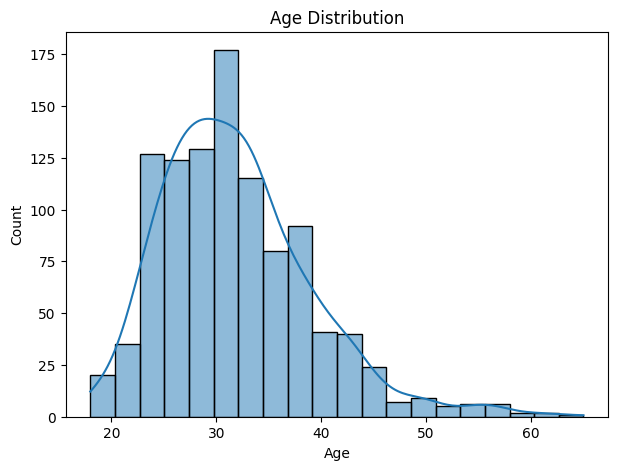

In [ ]:
plt.figure(figsize=(7,5))

sns.histplot(df["Age"], bins=20, kde=True)

plt.title("Age Distribution")

plt.show()

**Gender Distribution**

This visualization shows the gender composition of employees.

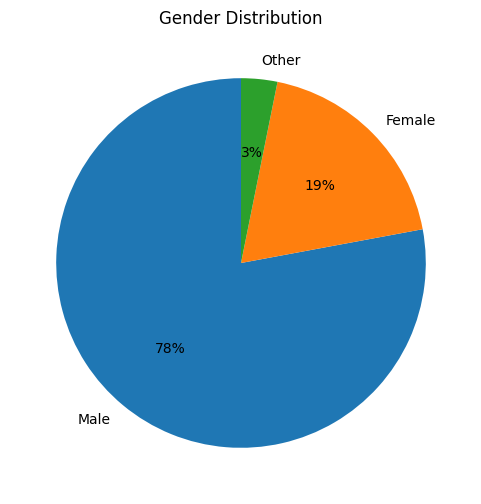

In [ ]:
gender_counts = df["Gender"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.0f%%",
    startangle=90
)

plt.title("Gender Distribution")

plt.show()

**Treatment Distribution**

This graph shows the number of employees who reported requiring mental health treatment.

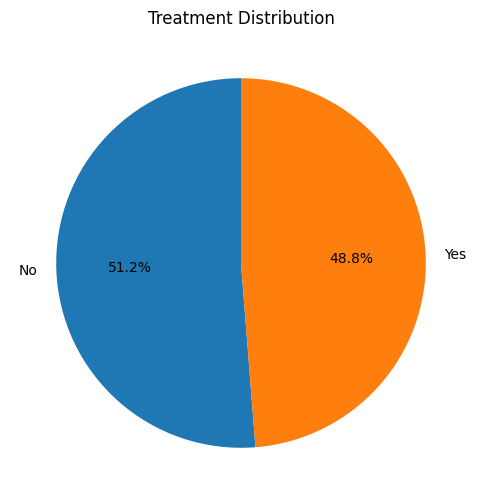

In [ ]:
treatment_counts = df["treatment"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    treatment_counts,
    labels=treatment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Treatment Distribution")

plt.show()

# EDA 1: Family History vs Treatment

## *Business* *Question*

Does having a family history of mental illness increase the likelihood of seeking mental health treatment?

## *Objective*

Family history is considered an important factor in mental health. This analysis helps determine whether employees with a family history are more likely to seek treatment. Understanding this relationship can help organizations identify high-risk groups and design targeted wellness initiatives.

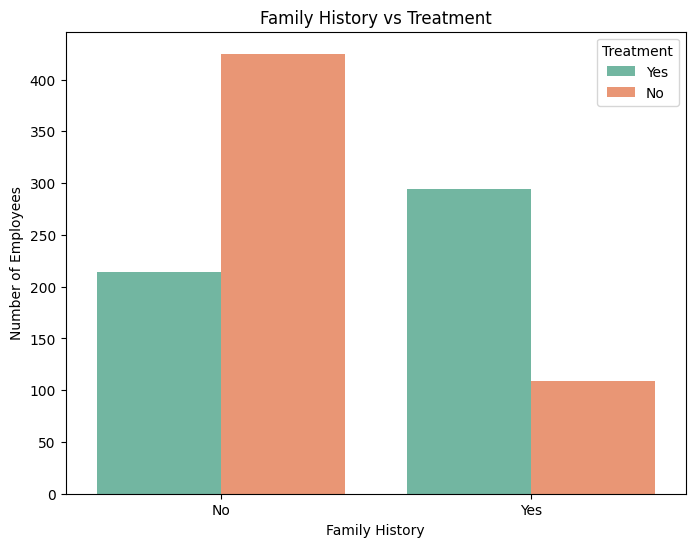

In [ ]:
plt.figure(figsize=(8,6))

sns.countplot(
    data=df,
    x="family_history",
    hue="treatment",
    palette="Set2"
)

plt.title("Family History vs Treatment")
plt.xlabel("Family History")
plt.ylabel("Number of Employees")

plt.legend(title="Treatment")

plt.show()

## **Business Insight**

Family history shows a strong association with mental health treatment. Employees who have a family history of mental illness are more likely to seek treatment, suggesting that hereditary or environmental factors may influence mental health outcomes.

Organizations can use this information to provide targeted awareness campaigns and proactive mental health support for employees who may be at greater risk.

# EDA 2: Work Interference vs Mental Health Treatment

## *Business Question*

Does mental health interfere with an employee's work performance, and how does it relate to seeking treatment?

## *Objective*

Mental health conditions can directly affect an employee's productivity and daily work performance. This analysis aims to determine whether employees who experience greater work interference due to mental health are more likely to seek treatment. The findings can help organizations identify employees who may require additional workplace support and wellness interventions.

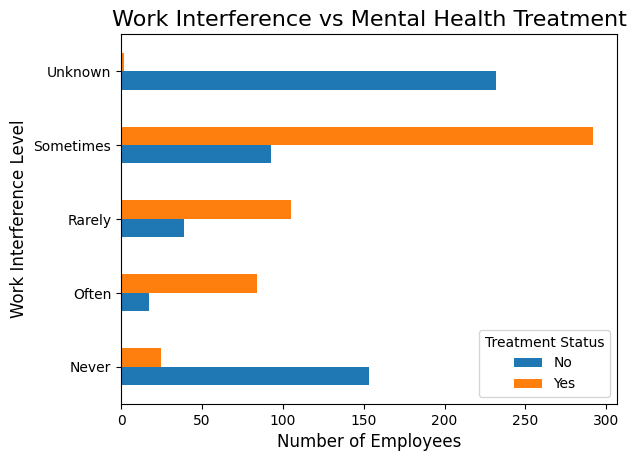

In [ ]:
pd.crosstab(df['work_interfere'], df['treatment']).plot(
    kind='barh'
)

plt.title("Work Interference vs Mental Health Treatment", fontsize=16)
plt.xlabel("Number of Employees", fontsize=12)
plt.ylabel("Work Interference Level", fontsize=12)
plt.legend(title="Treatment Status")

plt.show()

## **Observation**

The chart compares employees based on how much their mental health interferes with their work and whether they sought professional treatment.

Employees who reported that their mental health **often** or **sometimes** interfered with their work showed a noticeably higher proportion of treatment cases compared to employees who reported **rarely** or **never** experiencing work interference.

## **Business Insight**

The analysis indicates a strong relationship between work interference and mental health treatment. Employees experiencing frequent interference in their work due to mental health issues are more likely to seek treatment.

This suggests that declining work performance may serve as an early indicator of mental health concerns. Organizations should actively monitor employee well-being and encourage timely access to mental health resources before productivity is significantly affected.

# EDA 3: Employer Benefits vs Mental Health Treatment

## Business Question

Does the availability of employer-provided mental health benefits influence employees in seeking mental health treatment?

## Objective

Mental health benefits provided by employers play an important role in encouraging employees to seek professional support. This analysis examines whether employees working in organizations that provide mental health benefits are more likely to receive treatment.


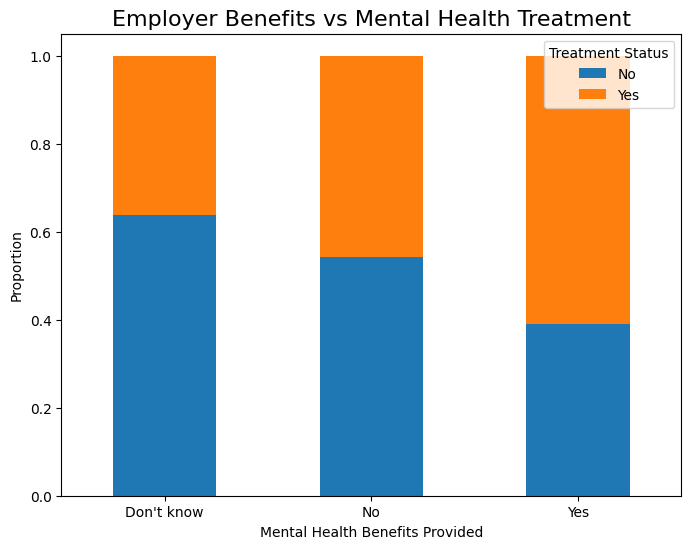

In [ ]:
table = pd.crosstab(
    df['benefits'],
    df['treatment'],
    normalize='index'
)

table.plot(kind='bar', stacked=True, figsize=(8,6))

plt.title("Employer Benefits vs Mental Health Treatment", fontsize=16)
plt.xlabel("Mental Health Benefits Provided")
plt.ylabel("Proportion")
plt.legend(title="Treatment Status")

plt.xticks(rotation=0)

plt.show()

## **Observation**

The visualization compares employees based on whether their organization provides mental health benefits and whether they sought treatment.

Employees working in organizations that provide mental health benefits tend to report higher treatment rates, indicating greater awareness and easier access to professional support.

## **Buisness Insight**

Providing mental health benefits reduces barriers to treatment and encourages employees to prioritize their mental well-being. Organizations offering these benefits demonstrate a stronger commitment to employee wellness.



# EDA 4: Wellness Program vs Mental Health Treatment

## Business Question

Do workplace wellness programs encourage employees to seek mental health treatment?

## Objective

Employee wellness programs are designed to improve awareness and reduce the stigma surrounding mental health. This analysis evaluates whether organizations with wellness programs have employees who are more likely to seek treatment.


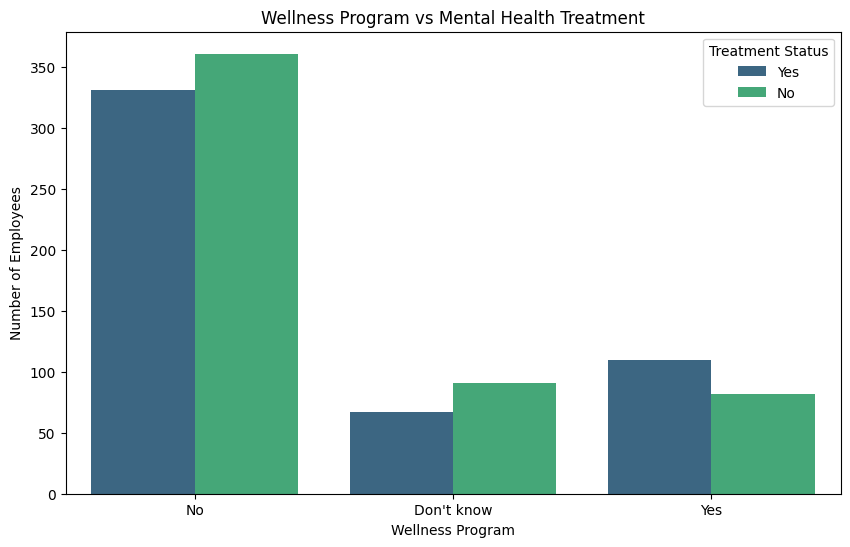

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="wellness_program",
    hue="treatment",
    palette="viridis"
)

plt.title("Wellness Program vs Mental Health Treatment")
plt.xlabel("Wellness Program")
plt.ylabel("Number of Employees")

plt.legend(title="Treatment Status")
plt.show()

## Observation

Employees working in organizations that conduct wellness programs show noticeable differences in treatment behavior compared to organizations without such initiatives.

## Business Insight

Wellness programs improve awareness of mental health issues, reduce stigma, and encourage employees to seek professional help when required.




# EDA 5: Seek Help Resources vs Mental Health Treatment

## Business Question

Does providing mental health resources encourage employees to seek treatment?

## Objective

Organizations often provide educational resources regarding mental health. This analysis evaluates whether access to these resources influences treatment behavior.

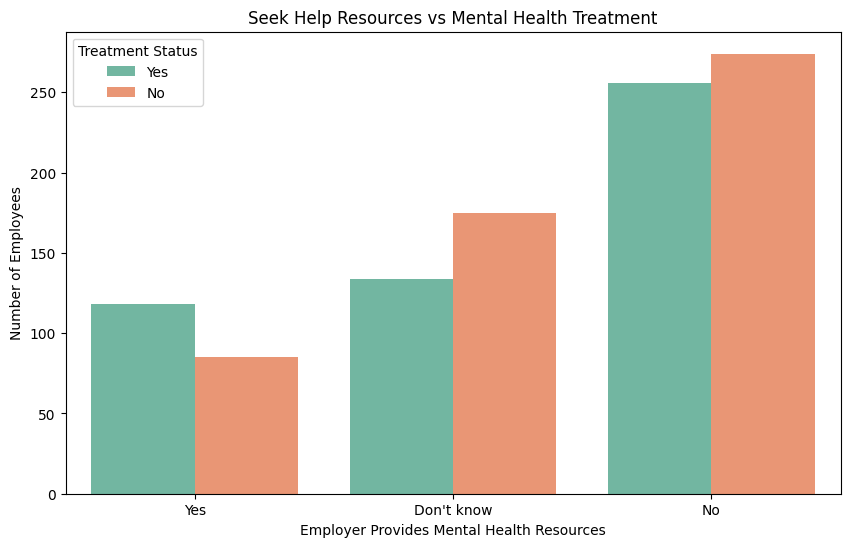

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="seek_help",
    hue="treatment",
    palette="Set2"
)

plt.title("Seek Help Resources vs Mental Health Treatment")
plt.xlabel("Employer Provides Mental Health Resources")
plt.ylabel("Number of Employees")

plt.legend(title="Treatment Status")
plt.show()

## Observation

Employees who have access to mental health resources demonstrate greater awareness and are generally more willing to seek treatment.

## Business Insight

Providing accessible mental health resources empowers employees to recognize symptoms early and seek professional support without hesitation.



# EDA 6: Supervisor Support vs Mental Health Treatment

## Business Question

Does support from supervisors influence employees in seeking mental health treatment?

## Objective

Managers and supervisors often play a critical role in creating a psychologically safe workplace. This analysis examines whether employees comfortable discussing mental health with supervisors are more likely to seek treatment.

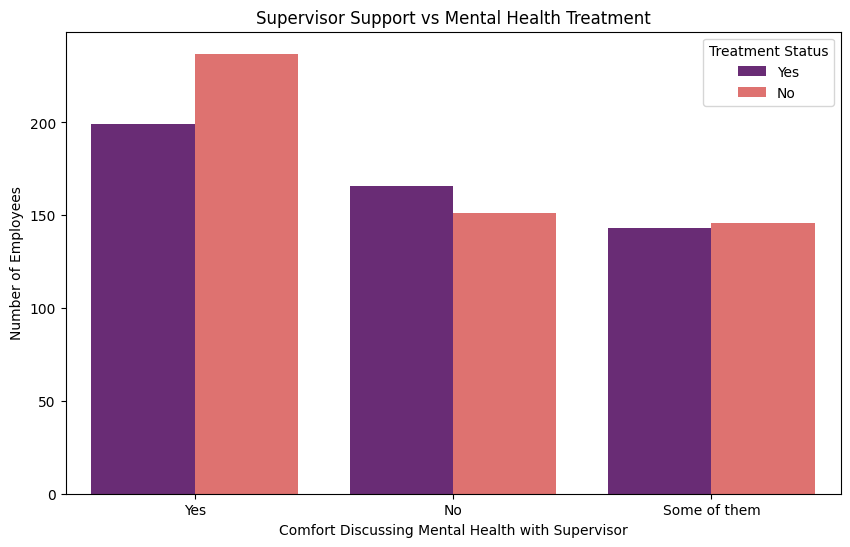

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="supervisor",
    hue="treatment",
    palette="magma"
)

plt.title("Supervisor Support vs Mental Health Treatment")
plt.xlabel("Comfort Discussing Mental Health with Supervisor")
plt.ylabel("Number of Employees")

plt.xticks(rotation=0)

plt.legend(title="Treatment Status")
plt.show()

# EDA 7: Coworker Support vs Mental Health Treatment

## Business Question

Does support from coworkers influence employees in seeking mental health treatment?

## Objective

A supportive workplace environment plays an essential role in improving employees' mental well-being. Employees who feel comfortable discussing their mental health with coworkers are more likely to receive emotional support, reduce feelings of isolation, and seek professional treatment when needed.

This analysis aims to understand whether the level of comfort in discussing mental health with coworkers is associated with employees seeking mental health treatment.


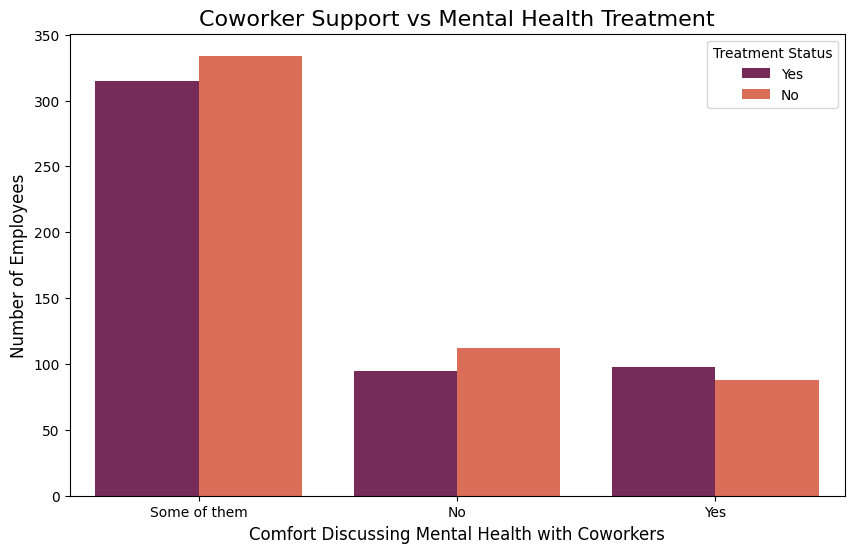

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="coworkers",
    hue="treatment",
    palette="rocket"
)

plt.title("Coworker Support vs Mental Health Treatment", fontsize=16)
plt.xlabel("Comfort Discussing Mental Health with Coworkers", fontsize=12)
plt.ylabel("Number of Employees", fontsize=12)

plt.legend(title="Treatment Status")

plt.show()

## Observation

The visualization compares employees based on their comfort level in discussing mental health with coworkers and whether they have sought professional treatment.

Employees who reported being comfortable discussing mental health with coworkers generally show higher treatment participation. Those who selected **"Some of them"** fall between the two extremes, suggesting that partial workplace support encourages treatment to some extent but is less effective than a fully supportive environment.

## Business Insight

A supportive coworker environment encourages open communication and reduces the stigma associated with mental health issues. Employees who feel psychologically safe are more likely to recognize mental health challenges and seek professional treatment when required.

Developing a positive workplace culture can improve employee well-being, strengthen collaboration, and create an environment where mental health discussions are accepted without fear of judgment.




# EDA 8: Remote Work vs Mental Health Treatment

## Business Question

Does working remotely influence employees' likelihood of seeking mental health treatment?

## Objective

Remote work has become an important part of modern workplaces. While it offers flexibility and improved work-life balance, it may also create challenges such as social isolation, communication gaps, and reduced team interaction.

This analysis examines whether employees working remotely differ from office-based employees in terms of seeking mental health treatment.


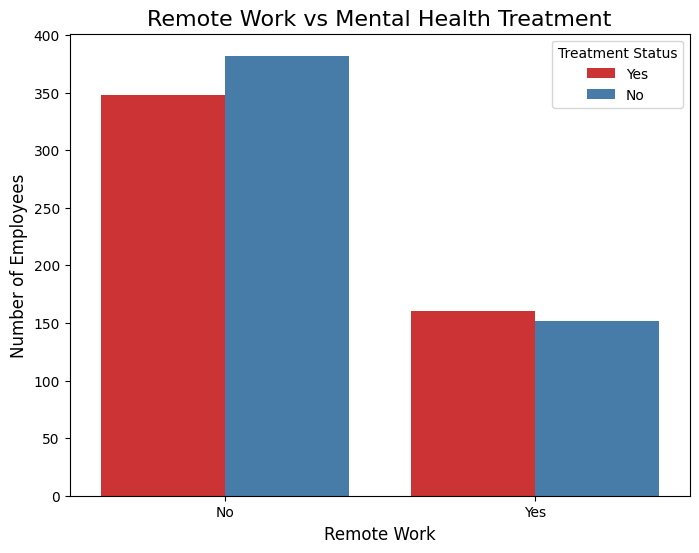

In [ ]:
plt.figure(figsize=(8,6))

sns.countplot(
    data=df,
    x="remote_work",
    hue="treatment",
    palette="Set1"
)

plt.title("Remote Work vs Mental Health Treatment", fontsize=16)
plt.xlabel("Remote Work", fontsize=12)
plt.ylabel("Number of Employees", fontsize=12)

plt.legend(title="Treatment Status")

plt.show()

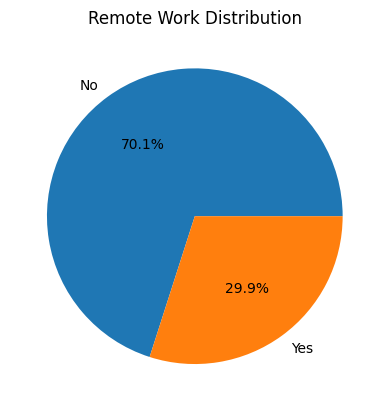

In [ ]:
remote = df["remote_work"].value_counts()

plt.pie(
    remote,
    labels=remote.index,
    autopct="%1.1f%%"
)

plt.title("Remote Work Distribution")
plt.show()

## Observation

The visualization compares employees working remotely with those working from the office based on whether they sought mental health treatment.

The analysis helps identify whether work location influences treatment-seeking behavior. Any noticeable difference between the two groups suggests that workplace environment and working style may affect employees' mental well-being.

## Business Insight

Remote work can have both positive and negative effects on mental health. Flexible work arrangements may reduce stress for some employees, while limited social interaction and isolation may increase mental health challenges for others.

Organizations should ensure that remote employees receive the same level of mental health support, communication, and access to wellness resources as employees working from the office.



# Correlational Analysis

Correlation analysis helps identify relationships among variables after encoding categorical features.

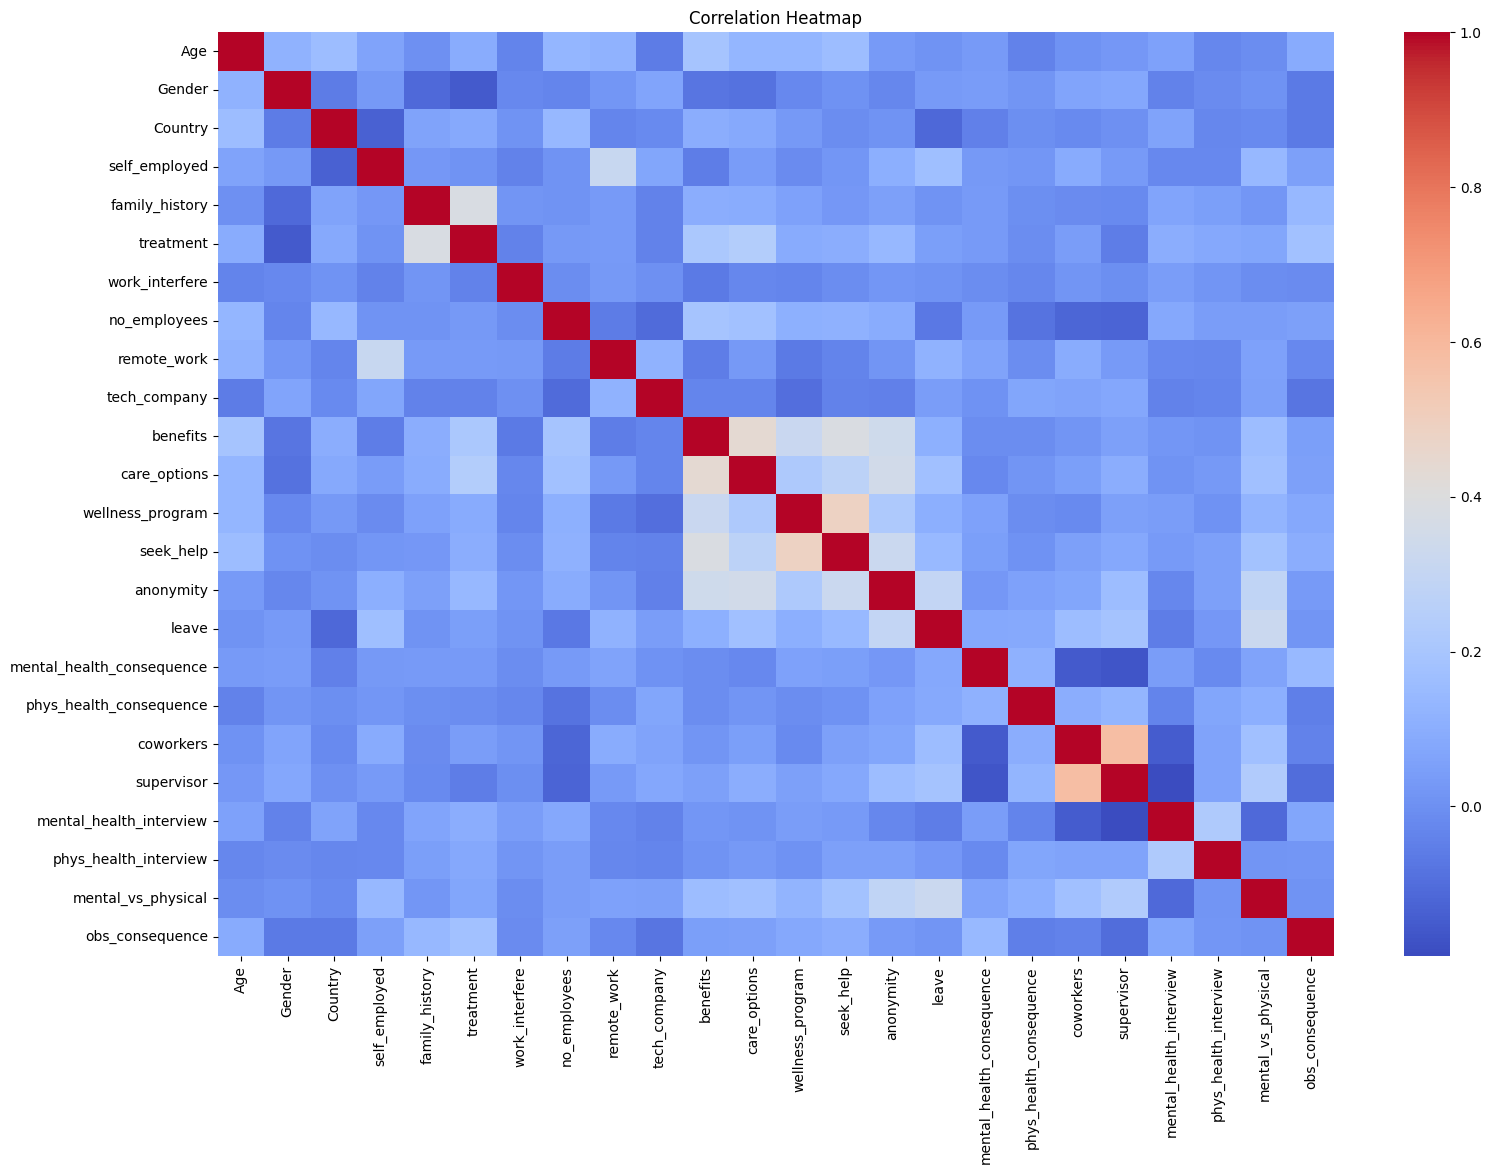

In [ ]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

le = LabelEncoder()

for col in df_encoded.columns:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

plt.figure(figsize=(18,12))

sns.heatmap(df_encoded.corr(),
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

# Statistical Significance Test

A Chi-Square test is used to determine whether there is a statistically significant relationship between categorical variables.

In [ ]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df["family_history"],
                    df["treatment"])

chi2,p,dof,expected = chi2_contingency(table)

print("P-value:",p)

if p < 0.05:
    print("There is a significant relationship.")
else:
    print("No significant relationship.")

P-value: 5.001084972839597e-35
There is a significant relationship.


# Key Findings

1. Employees with a family history of mental illness are significantly more likely to seek treatment.

2. Mental health interference with work strongly increases treatment requirements.

3. Organizations providing mental health benefits show higher treatment awareness.

4. Wellness programs encourage employees to seek professional support.

5. Employees with supportive supervisors and coworkers are generally more comfortable discussing mental health.

6. Remote work alone does not appear to have a strong influence on treatment-seeking behaviour.

# Recommendations

Based on the analysis, XYZ Technical Solutions should consider the following initiatives:

• Expand mental health awareness campaigns.

• Conduct regular employee wellness assessments.

• Increase access to counselling and mental health resources.

• Train supervisors to better support employees facing mental health challenges.

• Strengthen workplace wellness programs.

• Encourage open discussions regarding mental health while maintaining employee anonymity.

# Conclusion

This exploratory data analysis identified several workplace and personal factors associated with employees seeking mental health treatment. Family history, work interference, employer benefits, wellness programs, and workplace support all play important roles in influencing employee well-being. The insights obtained from this analysis can help XYZ Technical Solutions design targeted mental health initiatives, improve employee wellness programs, and foster a healthier and more supportive work environment.